# BioGen 2024 — Phase 1 Notebook

It covers:
- loading the BioGen topics and PubMed abstracts
- building OpenSearch indexes
- running **BM25**, **LM Jelinek-Mercer**, **LM Dirichlet**, and **dense k-NN** retrieval
- producing ranked runs
- evaluating with **Precision@10**, **Recall@100**, **NDCG**, and a simple **precision-recall curve**

In [1]:
import json
import math
import os
from pathlib import Path
from collections import defaultdict
import pprint as pp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from opensearchpy import OpenSearch, helpers
from opensearchpy.helpers import bulk

from sentence_transformers import SentenceTransformer

## 1) Configuration

Set your local paths and your OpenSearch connection.

In [2]:
# ---------------------------
# File paths
# ---------------------------
DATA_DIR = Path("./BioGen2024")

TOPICS_PATH = DATA_DIR / "BioGen2024topics.json"
CORPUS_PATH = DATA_DIR / "filtered_pubmed_abstracts.txt"
SUBMISSIONS_PATH = DATA_DIR / "biogen_2024_submissions.json"

# ---------------------------
# OpenSearch connection
# ---------------------------
OS_HOST = "api.novasearch.org"
OS_PORT = 443
OS_USER = "usernlp16"
OS_PASS = "hEatz?gz5K"

INDEX_NAME = OS_USER

# ---------------------------
# Dense retrieval model
# ---------------------------
EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

## 2) Load the data

### Load the corpus

In [3]:
def load_corpus_txt(path):
    docs = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            pmid = str(obj["id"])
            contents = obj["contents"].strip()

            parts = contents.split("\n", 1)
            title = parts[0].strip()
            abstract = parts[1].strip() if len(parts) > 1 else ""

            docs.append({
                "pmid": pmid,
                "title": title,
                "abstract": abstract
            })
    return docs

docs = load_corpus_txt(CORPUS_PATH)

print("Number of documents:", len(docs))
print(docs[0])

Number of documents: 4194
{'pmid': '61500', 'title': 'Oral methionine in the treatment of severe paracetamol (Acetaminophen) overdose.', 'abstract': '30 patients at risk of hepatic damage from paracetamol (acetaminophen) ingestion were given 2-5 g oral methionine every four hours up to a total dose of 10 g. The first dose was given within ten hours of the overdose. There were no deaths and no reports of hepatic encephalopathy or other complications. In 21 patients plasma aspartate-aminotransferase remained within normal limits. These results suggest that methionine may be effective in reducing the frequency and severity of paracetamol-induced liver damage and may provide an effective non-toxic alternative to cysteamine.'}


### Load the topics

In [4]:
def load_topics(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["topics"]

topics = load_topics(TOPICS_PATH)
print("Number of topics:", len(topics))
print(topics[0])

Number of topics: 65
{'id': 116, 'topic': 'natural treatments for sleep apnea', 'question': 'Are there ways to prevent sleep apnea or treat it naturally?', 'narrative': 'The patient is looking for natural remedies to prevent and treat sleep apnea.'}


## Build Query Text

In [5]:
queries = {
    str(t["id"]): f'{t["topic"]} {t["question"]} {t["narrative"]}'
    for t in topics
}

print("Number of queries:", len(queries))
first_qid = next(iter(queries))
print(first_qid, "->", queries[first_qid])

Number of queries: 65
116 -> natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.


## Split train/test

In [6]:
train_topics = [t for t in topics if int(t["id"]) % 2 == 1]
test_topics  = [t for t in topics if int(t["id"]) % 2 == 0]

print("Train:", len(train_topics))
print("Test:", len(test_topics))

Train: 32
Test: 33


## Build qrels from submissions

In [7]:
def build_qrels_from_submissions(path):
    with open(path, "r", encoding="utf-8") as f:
        submissions = json.load(f)

    qrels = defaultdict(dict)

    for item in submissions:
        qid = str(item["question_id"])
        answers = item.get("machine_generated_answers", {})

        for system_name, system_data in answers.items():
            if system_data.get("is_answer_accurate", "").lower() != "yes":
                continue

            for sent in system_data.get("answer_sentences", []):
                citations = sent.get("citation_assessment")
                if not citations:
                    continue

                # supporting, neutral, contradicting, not relevant
                for c in citations:
                    pmid = str(c.get("cited_pmid"))
                    relation = (c.get("evidence_relation") or "").strip().lower()

                    if relation == "supporting":
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 2)
                    elif relation == "neutral":
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 1)
                    elif relation in ["contradicting", "not relevant"]:
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 0)

    return dict(qrels)

qrels_graded = build_qrels_from_submissions(SUBMISSIONS_PATH)
print("Number of qids with qrels:", len(qrels_graded))

first_qid = list(qrels_graded.keys())[0]
print(first_qid, qrels_graded[first_qid])

Number of qids with qrels: 65
116 {'18461106': 2, '27155670': 0, '33659106': 2, '29517065': 2, '19037617': 2, '14971838': 2, '30722731': 2, '38022002': 2, '24118690': 2, '25771294': 2, '18250210': 2, '28126502': 2, '18982969': 2, '30177246': 2, '24037015': 0, '18651518': 2, '21603432': 2, '16944671': 2, '20875158': 2, '19201228': 2, '17762999': 2, '36088151': 2, '15162258': 2, '37532368': 2, '16944672': 2, '15334045': 2, '30204000': 2, '28901030': 2, '21642831': 2, '17131687': 2, '19744402': 2, '22014867': 2, '27134515': 2, '16493160': 2, '15611895': 2, '23669094': 2, '27689226': 2, '26394258': 2, '27242272': 2, '28287009': 2, '25407131': 2, '30054649': 2, '17699143': 2, '25937875': 2, '20362917': 2, '21881511': 2, '19362029': 0, '37969463': 0, '19710614': 2, '31699408': 2, '19536941': 2, '17508101': 0, '24223313': 1, '23493439': 0, '22420172': 0, '19011153': 2, '33510821': 2, '23493498': 2, '33610579': 0, '35625748': 0, '33713177': 2, '21728019': 2, '30709524': 2, '35965683': 2, '2020

## Connect to OpenSearch

In [8]:
client = OpenSearch(
    hosts = [{'host': OS_HOST, 'port': OS_PORT}],
    http_compress = True, # enables gzip compression for request bodies
    http_auth = (OS_USER, OS_PASS),
    use_ssl = True,
    url_prefix = 'opensearch_v3',
    verify_certs = False,
    ssl_assert_hostname = False,
    ssl_show_warn = False
)

if client.indices.exists(index=INDEX_NAME):

    resp = client.indices.open(index=INDEX_NAME)
    print(resp)

    print('\n----------------------------------------------------------------------------------- INDEX SETTINGS')
    settings = client.indices.get_settings(index=INDEX_NAME)
    pp.pprint(settings)

    print('\n----------------------------------------------------------------------------------- INDEX MAPPINGS')
    mappings = client.indices.get_mapping(index=INDEX_NAME)
    pp.pprint(mappings)

    print('\n----------------------------------------------------------------------------------- INDEX #DOCs')
    print(client.count(index=INDEX_NAME))
else:
    print("Index does not exist.")

{'acknowledged': True, 'shards_acknowledged': True}

----------------------------------------------------------------------------------- INDEX SETTINGS
{'usernlp16': {'settings': {'index': {'creation_date': '1777367108977',
                                      'knn': 'true',
                                      'knn.derived_source': {'enabled': 'true'},
                                      'number_of_replicas': '0',
                                      'number_of_shards': '4',
                                      'provided_name': 'usernlp16',
                                      'refresh_interval': '-1',
                                      'replication': {'type': 'DOCUMENT'},
                                      'similarity': {'dirichlet_similarity': {'mu': '150',
                                                                              'type': 'LMDirichlet'},
                                                     'jm_similarity': {'lambda': '0.5',
                          

## Create Index

In [9]:
client.indices.delete(index=INDEX_NAME)

index_body = {
    "settings": {
        "index": {
            "number_of_replicas": 0,
            "number_of_shards": 4,
            "refresh_interval": "-1",
            "knn": True,
            "similarity": {
                "jm_similarity": {
                    "type": "LMJelinekMercer",
                    "lambda": 0.5
                },
                "dirichlet_similarity": {
                    "type": "LMDirichlet",
                    "mu": 150
                }
            }
        }
    },
    "mappings": {
        "dynamic": "strict",
        "properties": {
            "pmid": {"type": "keyword"},
            "title": {"type": "text", "analyzer": "standard"},
            "abstract": {"type": "text", "analyzer": "standard"},

            "bm25_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "BM25"
            },
            "jelinek_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "jm_similarity"
            },
            "dirichlet_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "dirichlet_similarity"
            },

            "embedding": {
                "type": "knn_vector",
                "dimension": 768
            }
        }
    }
}

if client.indices.exists(index=INDEX_NAME):
    print("Index already existed. Nothing to be done.")
else:        
    response = client.indices.create(index=INDEX_NAME, body=index_body)
    print('\nCreating index:')
    print(response)


Creating index:
{'acknowledged': True, 'shards_acknowledged': True, 'index': 'usernlp16'}


## Choose embedding model

In [10]:
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Index the Documents

In [11]:
actions = [
    {
        "_index": INDEX_NAME,
        "_id": doc["pmid"],
        "_source": {
            "pmid": doc["pmid"],
            "title": doc["title"],
            "abstract": doc["abstract"],
            "bm25_content": doc["abstract"],
            "jelinek_content": doc["abstract"],
            "dirichlet_content": doc["abstract"],
            "embedding": embedder.encode(doc["abstract"]).tolist()
        }
    }
    for doc in docs
]

success, errors = helpers.bulk(client, actions)
client.indices.refresh(index=INDEX_NAME)
print(f"Indexed {success} documents. Errors: {errors}")

KeyboardInterrupt: 

## Retrievers

#### BM25

In [ ]:
def bm25_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "bm25_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### Jelinek-Mercer

In [ ]:
def jm_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "jelinek_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### Dirichlet

In [ ]:
def lmd_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "dirichlet_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### KNN

In [ ]:
def knn_search(query_text, index, embedder, n_results=100):
    query_vector = embedder.encode(query_text).tolist()

    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "knn": {
                    "embedding": {
                        "vector": query_vector,
                        "k": n_results
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

In [ ]:
qrels_binary = {
    qid: {pmid for pmid, rel in rels.items() if rel > 0}
    for qid, rels in qrels_graded.items()
}

print("Number of qrels queries:", len(qrels_binary))
example_qid = next(iter(qrels_binary))
print(example_qid, qrels_binary[example_qid])

Number of qrels queries: 65
116 {'30177246', '23669094', '17028491', '21642831', '38022002', '30722731', '33510821', '18982969', '28901030', '30709529', '33713177', '29517065', '19412478', '33659106', '36141367', '26321833', '20202954', '15162258', '15334045', '19710614', '20425226', '19037617', '24947878', '27134515', '19011153', '26394258', '36088151', '19201228', '35460431', '16944672', '28126502', '22014867', '19536941', '32334866', '18651518', '17699143', '36333079', '28287009', '37532368', '16493160', '15611895', '31699408', '24223313', '23493498', '21603432', '30054649', '25771294', '25407131', '25937875', '20362917', '35965683', '30709524', '24061345', '23293626', '17131687', '18461106', '14971838', '19744402', '24118690', '16944671', '30204000', '27242272', '20875158', '21728019', '28052557', '29058628', '30709526', '17762999', '21881511', '37082825', '27689226', '18250210'}


In [ ]:
from tqdm import tqdm

bm25_results = {}
jm_results = {}
lmd_results = {}
knn_results = {}

for qid, query_text in tqdm(queries.items(), desc="Running retrieval"):
    bm25_results[qid] = bm25_search(query_text, INDEX_NAME, n_results=100)
    jm_results[qid]   = jm_search(query_text, INDEX_NAME, n_results=100)
    lmd_results[qid]  = lmd_search(query_text, INDEX_NAME, n_results=100)
    knn_results[qid]  = knn_search(query_text, INDEX_NAME, embedder, n_results=100)

Running retrieval: 100%|██████████| 65/65 [00:13<00:00,  4.81it/s]


In [ ]:
sample_qid = next(iter(queries))
print("Query:", sample_qid)
print("Text:", queries[sample_qid])
print("BM25 top-5:", [x[0] for x in bm25_results[sample_qid][:5]])
print("JM top-5:", [x[0] for x in jm_results[sample_qid][:5]])
print("LMD top-5:", [x[0] for x in lmd_results[sample_qid][:5]])
print("KNN top-5:", [x[0] for x in knn_results[sample_qid][:5]])
print("Relevant:", qrels_binary.get(sample_qid, set()))

Query: 116
Text: natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.
BM25 top-5: ['23293626', '20425226', '36333079', '30177246', '19037617']
JM top-5: ['36333079', '23293626', '20425226', '20362917', '22014867']
LMD top-5: ['23293626', '20425226', '36333079', '12973373', '15611895']
KNN top-5: ['22014867', '37532368', '36088151', '15162258', '12973373']
Relevant: {'30177246', '23669094', '17028491', '21642831', '38022002', '30722731', '33510821', '18982969', '28901030', '30709529', '33713177', '29517065', '19412478', '33659106', '36141367', '26321833', '20202954', '15162258', '15334045', '19710614', '20425226', '19037617', '24947878', '27134515', '19011153', '26394258', '36088151', '19201228', '35460431', '16944672', '28126502', '22014867', '19536941', '32334866', '18651518', '17699143', '36333079', '28287009', '37532368', '16493160', '15611895', '31699408', '24223

## Metric Functions

In [ ]:
def precision_at_k(ranking, labels, k):
    top_k = ranking[:k]
    rel_in_top_k = sum(labels[i] for i in top_k)
    return rel_in_top_k / k


def recall_at_k(ranking, labels, k):
    total_relevant = sum(labels)
    if total_relevant == 0:
        return 0.0
    top_k = ranking[:k]
    rel_in_top_k = sum(labels[i] for i in top_k)
    return rel_in_top_k / total_relevant


def reciprocal_rank(ranking, labels):
    for rank_pos, doc_idx in enumerate(ranking, start=1):
        if labels[doc_idx]:
            return 1.0 / rank_pos
    return 0.0


def average_precision(ranking, labels):
    total_relevant = sum(labels)
    if total_relevant == 0:
        return 0.0

    num_rel_found = 0
    ap_sum = 0.0

    for rank_pos, doc_idx in enumerate(ranking, start=1):
        if labels[doc_idx]:
            num_rel_found += 1
            ap_sum += num_rel_found / rank_pos

    return ap_sum / total_relevant


def dcg_at_k(ranking, graded_labels, k):
    dcg = 0.0
    for i, doc_idx in enumerate(ranking[:k], start=1):
        rel = graded_labels[doc_idx]
        dcg += (2**rel - 1) / np.log2(i + 1)
    return dcg


def ndcg_at_k(ranking, graded_labels, k):
    dcg = dcg_at_k(ranking, graded_labels, k)

    ideal_ranking = sorted(
        range(len(graded_labels)),
        key=lambda i: graded_labels[i],
        reverse=True
    )
    idcg = dcg_at_k(ideal_ranking, graded_labels, k)

    if idcg == 0:
        return 0.0
    return dcg / idcg

## Compute Retrieval Metrics

### Convert Results into Ranking

In [ ]:
def results_to_ranking(results, qrels_set, all_doc_ids):
    """
    Convert OpenSearch results to:
    - relevance_labels: boolean list aligned with all_doc_ids
    - ranking: indices into all_doc_ids ordered by retrieval rank
    """
    id_to_idx = {doc_id: i for i, doc_id in enumerate(all_doc_ids)}

    relevance = [doc_id in qrels_set for doc_id in all_doc_ids]

    retrieved_ids = [doc_id for doc_id, _ in results if doc_id in id_to_idx]
    retrieved_set = set(retrieved_ids)

    not_retrieved = [doc_id for doc_id in all_doc_ids if doc_id not in retrieved_set]
    full_ranking_ids = retrieved_ids + not_retrieved

    ranking = [id_to_idx[doc_id] for doc_id in full_ranking_ids]

    return relevance, ranking

def results_to_ranking_with_graded_labels(results, qrels_graded_for_qid, all_doc_ids):
    """
    Same as above, but returns graded labels for NDCG.
    """
    id_to_idx = {doc_id: i for i, doc_id in enumerate(all_doc_ids)}

    graded_labels = [qrels_graded_for_qid.get(doc_id, 0) for doc_id in all_doc_ids]

    retrieved_ids = [doc_id for doc_id, _ in results if doc_id in id_to_idx]
    retrieved_set = set(retrieved_ids)

    not_retrieved = [doc_id for doc_id in all_doc_ids if doc_id not in retrieved_set]
    full_ranking_ids = retrieved_ids + not_retrieved

    ranking = [id_to_idx[doc_id] for doc_id in full_ranking_ids]

    return graded_labels, ranking

### Helpers

In [ ]:
def build_eval_queries(run_results, queries, qrels_binary, qrels_graded, all_doc_ids):
    eval_queries_bin = []
    eval_queries_graded = []

    for qid in queries:
        labels_bin, ranking = results_to_ranking(
            run_results[qid],
            qrels_binary.get(qid, set()),
            all_doc_ids
        )

        labels_graded, ranking2 = results_to_ranking_with_graded_labels(
            run_results[qid],
            qrels_graded.get(qid, {}),
            all_doc_ids
        )

        eval_queries_bin.append((qid, labels_bin, ranking))
        eval_queries_graded.append((qid, labels_graded, ranking2))

    return eval_queries_bin, eval_queries_graded

### Evaluation

In [ ]:
def evaluate_run(run_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="RUN"):
    eval_queries_bin, eval_queries_graded = build_eval_queries(
        run_results, queries, qrels_binary, qrels_graded, all_doc_ids
    )

    graded_lookup = {
        qid: (graded_labels, ranking)
        for qid, graded_labels, ranking in eval_queries_graded
    }

    print(f"\n=== {run_name} ===")
    print(f"{'Query':>5} | {'AP':>6} | {'RR':>6} | {'P@10':>6} | {'R@100':>7} | {'NDCG@10':>8} | {'NDCG@100':>9}")
    print("-" * 72)

    all_ap, all_rr = [], []
    all_p10, all_r100 = [], []
    all_ndcg10, all_ndcg100 = [], []

    rows = []

    for qid, labels, ranking in eval_queries_bin:
        graded_labels, _ = graded_lookup[qid]

        ap = average_precision(ranking, labels)
        rr = reciprocal_rank(ranking, labels)
        p10 = precision_at_k(ranking, labels, 10)
        r100 = recall_at_k(ranking, labels, 100)
        ndcg10 = ndcg_at_k(ranking, graded_labels, 10)
        ndcg100 = ndcg_at_k(ranking, graded_labels, 100)

        all_ap.append(ap)
        all_rr.append(rr)
        all_p10.append(p10)
        all_r100.append(r100)
        all_ndcg10.append(ndcg10)
        all_ndcg100.append(ndcg100)

        rows.append({
            "Query": qid,
            "AP": ap,
            "RR": rr,
            "P@10": p10,
            "R@100": r100,
            "NDCG@10": ndcg10,
            "NDCG@100": ndcg100
        })

        print(f"{qid:>5} | {ap:>6.3f} | {rr:>6.3f} | {p10:>6.3f} | {r100:>7.3f} | {ndcg10:>8.3f} | {ndcg100:>9.3f}")

    print("-" * 72)
    print(f"{'Mean':>5} | {np.mean(all_ap):>6.3f} | {np.mean(all_rr):>6.3f} | {np.mean(all_p10):>6.3f} | {np.mean(all_r100):>7.3f} | {np.mean(all_ndcg10):>8.3f} | {np.mean(all_ndcg100):>9.3f}")

    df_run = pd.DataFrame(rows)

    mean_row = pd.DataFrame([{
        "Query": "Mean",
        "AP": np.mean(all_ap),
        "RR": np.mean(all_rr),
        "P@10": np.mean(all_p10),
        "R@100": np.mean(all_r100),
        "NDCG@10": np.mean(all_ndcg10),
        "NDCG@100": np.mean(all_ndcg100)
    }])

    df_run = pd.concat([df_run, mean_row], ignore_index=True)

    print(f"\nMAP       = {np.mean(all_ap):.4f}")
    print(f"MRR       = {np.mean(all_rr):.4f}")
    print(f"P@10      = {np.mean(all_p10):.4f}")
    print(f"R@100     = {np.mean(all_r100):.4f}")
    print(f"NDCG@10   = {np.mean(all_ndcg10):.4f}")
    print(f"NDCG@100  = {np.mean(all_ndcg100):.4f}")

    return {
        "MAP": np.mean(all_ap),
        "MRR": np.mean(all_rr),
        "P@10": np.mean(all_p10),
        "R@100": np.mean(all_r100),
        "NDCG@10": np.mean(all_ndcg10),
        "NDCG@100": np.mean(all_ndcg100),
        "eval_queries_bin": eval_queries_bin,
        "df": df_run
    }

## Evaluate each Retrieval Method

In [ ]:
all_doc_ids = [doc["pmid"] for doc in docs]
print("Total documents:", len(all_doc_ids))

metrics_bm25 = evaluate_run(
    bm25_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="BM25"
)
df_bm25 = metrics_bm25["df"]

metrics_jm = evaluate_run(
    jm_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="JM"
)
df_jm = metrics_jm["df"]

metrics_lmd = evaluate_run(
    lmd_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="LMD"
)
df_lmd = metrics_lmd["df"]

metrics_knn = evaluate_run(
    knn_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="KNN"
)
df_knn = metrics_knn["df"]


Total documents: 4194

=== BM25 ===
Query |     AP |     RR |   P@10 |   R@100 |  NDCG@10 |  NDCG@100
------------------------------------------------------------------------
  116 |  0.823 |  1.000 |  0.800 |   0.958 |    0.784 |     0.916
  117 |  0.766 |  1.000 |  1.000 |   0.838 |    1.000 |     0.867
  118 |  0.429 |  0.500 |  0.800 |   0.708 |    0.695 |     0.641
  119 |  0.613 |  0.500 |  0.600 |   0.867 |    0.450 |     0.764
  120 |  0.509 |  1.000 |  0.900 |   0.608 |    0.841 |     0.660
  121 |  0.338 |  0.250 |  0.600 |   0.589 |    0.467 |     0.544
  122 |  0.513 |  0.500 |  0.400 |   0.878 |    0.417 |     0.727
  123 |  0.526 |  1.000 |  0.500 |   0.776 |    0.573 |     0.740
  124 |  0.373 |  0.333 |  0.300 |   0.964 |    0.128 |     0.618
  125 |  0.666 |  0.500 |  0.700 |   0.889 |    0.612 |     0.808
  126 |  0.364 |  1.000 |  0.300 |   0.673 |    0.253 |     0.575
  127 |  0.734 |  1.000 |  0.800 |   0.875 |    0.807 |     0.862
  128 |  0.794 |  1.000 |  1.000 

In [ ]:
summary_df = pd.DataFrame([
    {"Run": "BM25", "MAP": metrics_bm25["MAP"], "MRR": metrics_bm25["MRR"], "P@10": metrics_bm25["P@10"], "R@100": metrics_bm25["R@100"], "NDCG@10": metrics_bm25["NDCG@10"], "NDCG@100": metrics_bm25["NDCG@100"]},
    {"Run": "JM",   "MAP": metrics_jm["MAP"],   "MRR": metrics_jm["MRR"],   "P@10": metrics_jm["P@10"],   "R@100": metrics_jm["R@100"],   "NDCG@10": metrics_jm["NDCG@10"],   "NDCG@100": metrics_jm["NDCG@100"]},
    {"Run": "LMD",  "MAP": metrics_lmd["MAP"],  "MRR": metrics_lmd["MRR"],  "P@10": metrics_lmd["P@10"],  "R@100": metrics_lmd["R@100"],  "NDCG@10": metrics_lmd["NDCG@10"],  "NDCG@100": metrics_lmd["NDCG@100"]},
    {"Run": "KNN",  "MAP": metrics_knn["MAP"],  "MRR": metrics_knn["MRR"],  "P@10": metrics_knn["P@10"],  "R@100": metrics_knn["R@100"],  "NDCG@10": metrics_knn["NDCG@10"],  "NDCG@100": metrics_knn["NDCG@100"]},
])

summary_df = summary_df.sort_values(by="NDCG@10", ascending=False).reset_index(drop=True)
summary_df

,Run,MAP,MRR,P@10,R@100,NDCG@10,NDCG@100
0,KNN,0.679596,0.840256,0.772308,0.897090,0.745099,0.830935
1,JM,0.563101,0.835641,0.701538,0.791174,0.676450,0.735243
2,BM25,0.584926,0.815385,0.687692,0.818551,0.659066,0.752562
3,LMD,0.552783,0.814249,0.689231,0.789264,0.652042,0.727243


## Inspect each Method Dataframe

In [ ]:
df_bm25.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.823449,1.0,0.8,0.958333,0.783841,0.916044
1,117,0.766283,1.0,1.0,0.837838,1.000000,0.867156
2,118,0.429140,0.5,0.8,0.708333,0.694765,0.640607
3,119,0.613037,0.5,0.6,0.866667,0.449750,0.763542
4,120,0.509053,1.0,0.9,0.607595,0.841493,0.660012


In [ ]:
df_jm.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.811687,1.0,0.8,0.944444,0.710477,0.886051
1,117,0.743168,1.0,1.0,0.837838,1.000000,0.862783
2,118,0.421457,0.5,0.7,0.708333,0.637889,0.638965
3,119,0.573405,0.5,0.5,0.816667,0.390740,0.727766
4,120,0.468856,1.0,0.8,0.594937,0.734325,0.628809


In [ ]:
df_lmd.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.787252,1.0,0.8,0.944444,0.714314,0.892533
1,117,0.727198,1.0,0.9,0.837838,0.926636,0.854767
2,118,0.487318,1.0,0.8,0.708333,0.831848,0.721520
3,119,0.587837,1.0,0.7,0.816667,0.538110,0.738713
4,120,0.500673,1.0,0.9,0.607595,0.779868,0.648800


In [ ]:
df_knn.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.862428,1.0,0.9,0.986111,0.914857,0.953798
1,117,0.756585,1.0,0.8,0.851351,0.870125,0.868382
2,118,0.763765,1.0,0.9,1.000000,0.933746,0.937530
3,119,0.747211,0.5,0.8,0.966667,0.648478,0.862462
4,120,0.628091,1.0,1.0,0.721519,0.951091,0.794926


## PR Curve

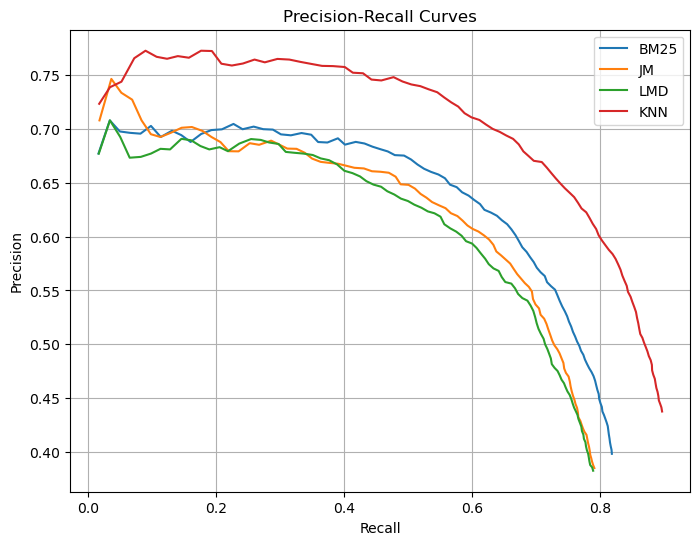

In [ ]:
def precision_recall_curve(eval_queries, max_k=100):
    mean_precisions = []
    mean_recalls = []

    for k in range(1, max_k + 1):
        ps, rs = [], []

        for _, labels, ranking in eval_queries:
            ps.append(precision_at_k(ranking, labels, k))
            rs.append(recall_at_k(ranking, labels, k))

        mean_precisions.append(np.mean(ps))
        mean_recalls.append(np.mean(rs))

    return mean_recalls, mean_precisions


rec_bm25, prec_bm25 = precision_recall_curve(metrics_bm25["eval_queries_bin"], max_k=100)
rec_jm, prec_jm = precision_recall_curve(metrics_jm["eval_queries_bin"], max_k=100)
rec_lmd, prec_lmd = precision_recall_curve(metrics_lmd["eval_queries_bin"], max_k=100)
rec_knn, prec_knn = precision_recall_curve(metrics_knn["eval_queries_bin"], max_k=100)

plt.figure(figsize=(8, 6))
plt.plot(rec_bm25, prec_bm25, label="BM25")
plt.plot(rec_jm, prec_jm, label="JM")
plt.plot(rec_lmd, prec_lmd, label="LMD")
plt.plot(rec_knn, prec_knn, label="KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## Evaluation only on test topics

In [ ]:
test_query_ids = {str(t["id"]) for t in test_topics}

queries_test = {qid: qtext for qid, qtext in queries.items() if qid in test_query_ids}
qrels_graded_test = {qid: rels for qid, rels in qrels_graded.items() if qid in test_query_ids}
qrels_binary_test = {qid: rels for qid, rels in qrels_binary.items() if qid in test_query_ids}

bm25_results_test = {qid: res for qid, res in bm25_results.items() if qid in test_query_ids}
jm_results_test   = {qid: res for qid, res in jm_results.items() if qid in test_query_ids}
lmd_results_test  = {qid: res for qid, res in lmd_results.items() if qid in test_query_ids}
knn_results_test  = {qid: res for qid, res in knn_results.items() if qid in test_query_ids}

In [ ]:
metrics_bm25_test = evaluate_run(
    bm25_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="BM25 TEST"
)
df_bm25_test = metrics_bm25_test["df"]

metrics_jm_test = evaluate_run(
    jm_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="JM TEST"
)
df_jm_test = metrics_jm_test["df"]

metrics_lmd_test = evaluate_run(
    lmd_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="LMD TEST"
)
df_lmd_test = metrics_lmd_test["df"]

metrics_knn_test = evaluate_run(
    knn_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="KNN TEST"
)
df_knn_test = metrics_knn_test["df"]


=== BM25 TEST ===
Query |     AP |     RR |   P@10 |   R@100 |  NDCG@10 |  NDCG@100
------------------------------------------------------------------------
  116 |  0.823 |  1.000 |  0.800 |   0.958 |    0.784 |     0.916
  118 |  0.429 |  0.500 |  0.800 |   0.708 |    0.695 |     0.641
  120 |  0.509 |  1.000 |  0.900 |   0.608 |    0.841 |     0.660
  122 |  0.513 |  0.500 |  0.400 |   0.878 |    0.417 |     0.727
  124 |  0.373 |  0.333 |  0.300 |   0.964 |    0.128 |     0.618
  126 |  0.364 |  1.000 |  0.300 |   0.673 |    0.253 |     0.575
  128 |  0.794 |  1.000 |  1.000 |   0.917 |    0.951 |     0.907
  130 |  0.806 |  1.000 |  0.700 |   1.000 |    0.690 |     0.923
  132 |  0.816 |  0.333 |  0.800 |   0.963 |    0.641 |     0.888
  134 |  0.802 |  1.000 |  1.000 |   0.877 |    0.954 |     0.885
  136 |  0.551 |  1.000 |  0.600 |   0.831 |    0.604 |     0.751
  138 |  0.821 |  1.000 |  0.700 |   1.000 |    0.605 |     0.775
  140 |  0.148 |  1.000 |  0.400 |   0.365 |    0.

In [ ]:
summary_df_test = pd.DataFrame([
    {"Run": "BM25", "MAP": metrics_bm25_test["MAP"], "MRR": metrics_bm25_test["MRR"], "P@10": metrics_bm25_test["P@10"], "R@100": metrics_bm25_test["R@100"], "NDCG@10": metrics_bm25_test["NDCG@10"], "NDCG@100": metrics_bm25_test["NDCG@100"]},
    {"Run": "JM",   "MAP": metrics_jm_test["MAP"],   "MRR": metrics_jm_test["MRR"],   "P@10": metrics_jm_test["P@10"],   "R@100": metrics_jm_test["R@100"],   "NDCG@10": metrics_jm_test["NDCG@10"],   "NDCG@100": metrics_jm_test["NDCG@100"]},
    {"Run": "LMD",  "MAP": metrics_lmd_test["MAP"],  "MRR": metrics_lmd_test["MRR"],  "P@10": metrics_lmd_test["P@10"],  "R@100": metrics_lmd_test["R@100"],  "NDCG@10": metrics_lmd_test["NDCG@10"],  "NDCG@100": metrics_lmd_test["NDCG@100"]},
    {"Run": "KNN",  "MAP": metrics_knn_test["MAP"],  "MRR": metrics_knn_test["MRR"],  "P@10": metrics_knn_test["P@10"],  "R@100": metrics_knn_test["R@100"],  "NDCG@10": metrics_knn_test["NDCG@10"],  "NDCG@100": metrics_knn_test["NDCG@100"]},
])

summary_df_test = summary_df_test.sort_values(by="NDCG@10", ascending=False).reset_index(drop=True)
summary_df_test

,Run,MAP,MRR,P@10,R@100,NDCG@10,NDCG@100
0,KNN,0.671876,0.825758,0.748485,0.894573,0.720673,0.824683
1,JM,0.569272,0.849495,0.675758,0.808040,0.650292,0.740403
2,BM25,0.597935,0.863636,0.666667,0.843492,0.641706,0.765192
3,LMD,0.565890,0.866162,0.663636,0.810352,0.631467,0.737407


## PR Curve Test

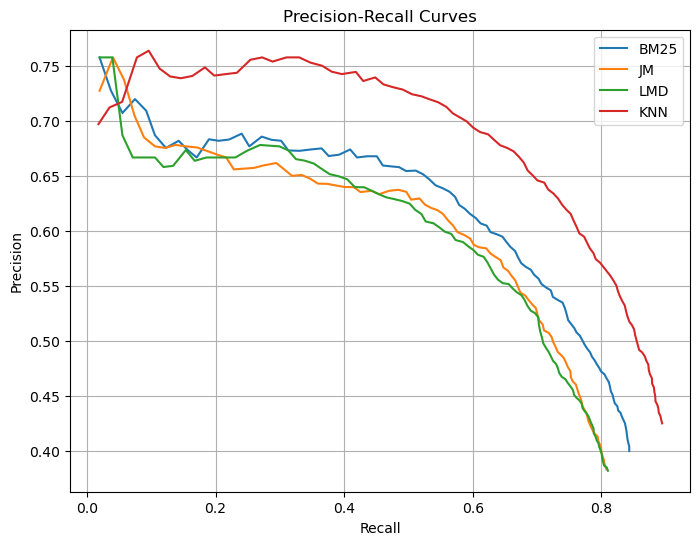

In [ ]:
rec_bm25_test, prec_bm25_test = precision_recall_curve(metrics_bm25_test["eval_queries_bin"], max_k=100)
rec_jm_test, prec_jm_test = precision_recall_curve(metrics_jm_test["eval_queries_bin"], max_k=100)
rec_lmd_test, prec_lmd_test = precision_recall_curve(metrics_lmd_test["eval_queries_bin"], max_k=100)
rec_knn_test, prec_knn_test = precision_recall_curve(metrics_knn_test["eval_queries_bin"], max_k=100)

plt.figure(figsize=(8, 6))
plt.plot(rec_bm25_test, prec_bm25_test, label="BM25")
plt.plot(rec_jm_test, prec_jm_test, label="JM")
plt.plot(rec_lmd_test, prec_lmd_test, label="LMD")
plt.plot(rec_knn_test, prec_knn_test, label="KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

### Query with highest and lowes AP

In [ ]:
# Remove mean row
df = df_knn_test[df_knn_test["Query"] != "Mean"].copy()

# Convert AP to numeric just in case
df["AP"] = df["AP"].astype(float)

# Highest AP
best_query = df.sort_values("AP", ascending=False).iloc[0]["Query"]

# Lowest AP
worst_query = df.sort_values("AP", ascending=True).iloc[0]["Query"]

# Middle query (median AP)
middle_query = df.sort_values("AP").iloc[len(df)//2]["Query"]

print("Best:", best_query)
print("Worst:", worst_query)
print("Middle:", middle_query)

Best: 170
Worst: 156
Middle: 164


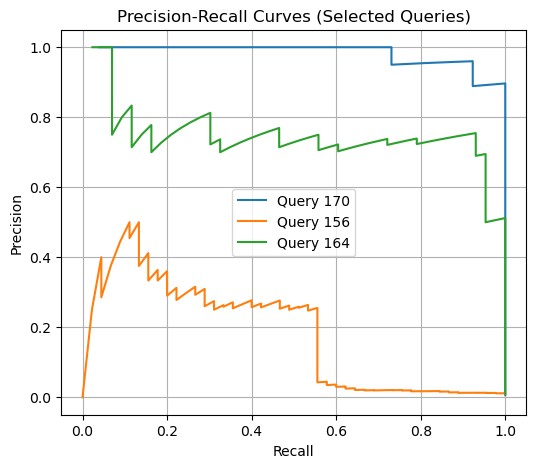

In [ ]:
def precision_recall_curve_single(ranking, labels):
    precisions = []
    recalls = []

    total_relevant = sum(labels)
    if total_relevant == 0:
        return [0], [0]

    rel_found = 0

    for k in range(1, len(ranking) + 1):
        doc_idx = ranking[k-1]

        if labels[doc_idx]:
            rel_found += 1

        precision = rel_found / k
        recall = rel_found / total_relevant

        precisions.append(precision)
        recalls.append(recall)

    return recalls, precisions

selected_qids = [best_query, worst_query, middle_query]

plt.figure(figsize=(6,5))

for qid in selected_qids:
    for q, labels, ranking in metrics_knn_test["eval_queries_bin"]:
        if q == qid:
            recalls, precisions = precision_recall_curve_single(ranking, labels)
            plt.plot(recalls, precisions, label=f"Query {qid}")
            break

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Selected Queries)")
plt.legend()
plt.grid()

plt.show()

## Save Results

In [ ]:
import json
from pathlib import Path

# document dictionary
doc_by_pmid = {doc["pmid"]: doc for doc in docs}

output_dir = Path("outputs/phase1_outputs")
output_dir.mkdir(exist_ok=True)

phase1_knn_outputs = {}

for qid, query_text in queries_test.items():
    results = knn_results_test[qid]

    phase1_knn_outputs[qid] = {
        "query": query_text,
        "method": "KNN",
        "results": []
    }

    for rank, (pmid, score) in enumerate(results, start=1):
        doc = doc_by_pmid.get(pmid, {})

        phase1_knn_outputs[qid]["results"].append({
            "rank": rank,
            "pmid": pmid,
            "score": float(score),
            "title": doc.get("title", ""),
            "abstract": doc.get("abstract", "")
        })

with open(output_dir / "retrieved_docs_knn.json", "w", encoding="utf-8") as f:
    json.dump(phase1_knn_outputs, f, indent=2, ensure_ascii=False)

# Phase 2: Factually Grounded RAG

## Exercise

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [ ]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Positional Embeddings

In [ ]:
word = "medicine"
text = " ".join([word] * 200)

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=202  # CLS + 200 tokens + SEP
)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens[:10], "...", tokens[-10:])

['[CLS]', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine'] ... ['medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', '[SEP]']


In [ ]:
with torch.no_grad():
    position_embeddings = model.embeddings.position_embeddings.weight

# positions for the real token sequence
seq_len = inputs["input_ids"].shape[1]
pos_embs = position_embeddings[:seq_len].detach().cpu().numpy()

# remove CLS and SEP
token_pos_embs = pos_embs[1:-1]
token_labels = tokens[1:-1]

print(token_pos_embs.shape)

(200, 768)


#### 2a.Distance to first token

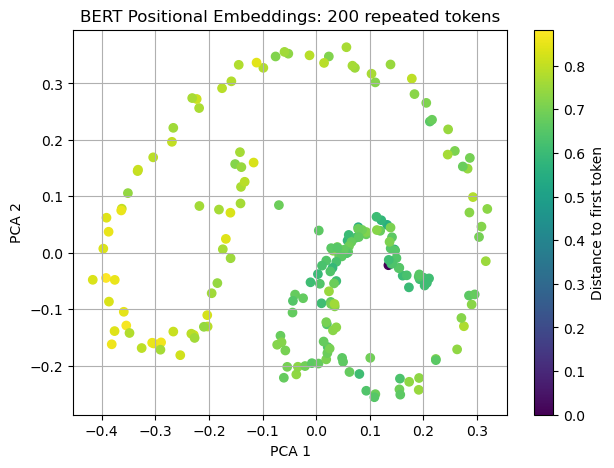

In [ ]:
dist_to_first = np.linalg.norm(token_pos_embs - token_pos_embs[0], axis=1)

pca = PCA(n_components=2)
pos_2d = pca.fit_transform(token_pos_embs)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=dist_to_first
)
plt.colorbar(scatter, label="Distance to first token")
plt.title("BERT Positional Embeddings: 200 repeated tokens")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

#### 2b. Distance matrix

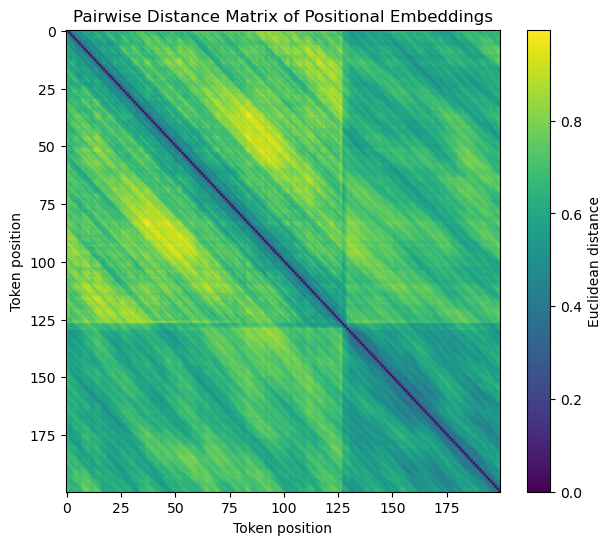

In [ ]:
dist_matrix = pairwise_distances(token_pos_embs, metric="euclidean")

plt.figure(figsize=(7, 6))
plt.imshow(dist_matrix, aspect="auto")
plt.colorbar(label="Euclidean distance")
plt.title("Pairwise Distance Matrix of Positional Embeddings")
plt.xlabel("Token position")
plt.ylabel("Token position")
plt.show()

### Contextual embeddings from layer 0 to 11

In [ ]:
text = "Sleep apnea can be improved by weight loss, avoiding alcohol, and positional therapy."

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Number of layers:", len(hidden_states))
print(tokens)

Number of layers: 13
['[CLS]', 'sleep', 'ap', '##nea', 'can', 'be', 'improved', 'by', 'weight', 'loss', ',', 'avoiding', 'alcohol', ',', 'and', 'position', '##al', 'therapy', '.', '[SEP]']


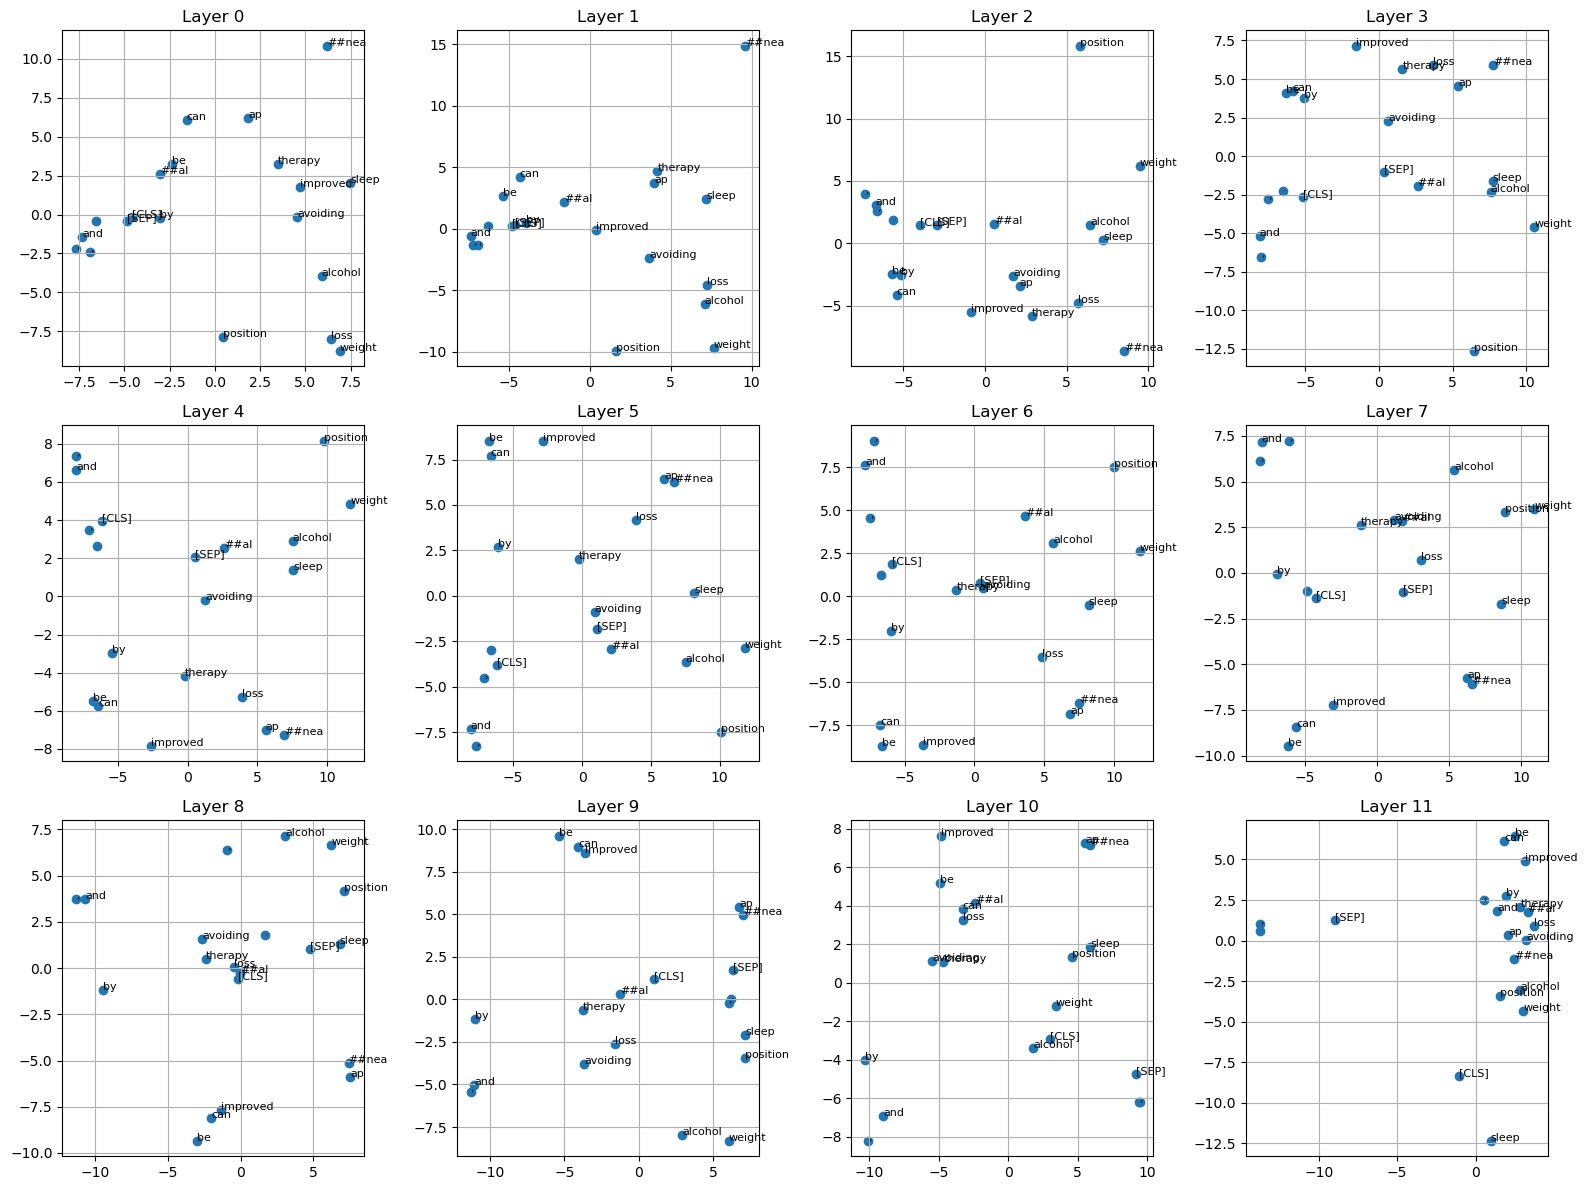

In [ ]:
layers = hidden_states[1:]  # 12 BERT layers

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for layer_idx, layer_tensor in enumerate(layers):
    emb = layer_tensor[0].detach().cpu().numpy()

    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)

    ax = axes[layer_idx]
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1])

    for i, token in enumerate(tokens):
        ax.annotate(token, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8)

    ax.set_title(f"Layer {layer_idx}")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Self-attention Visualization

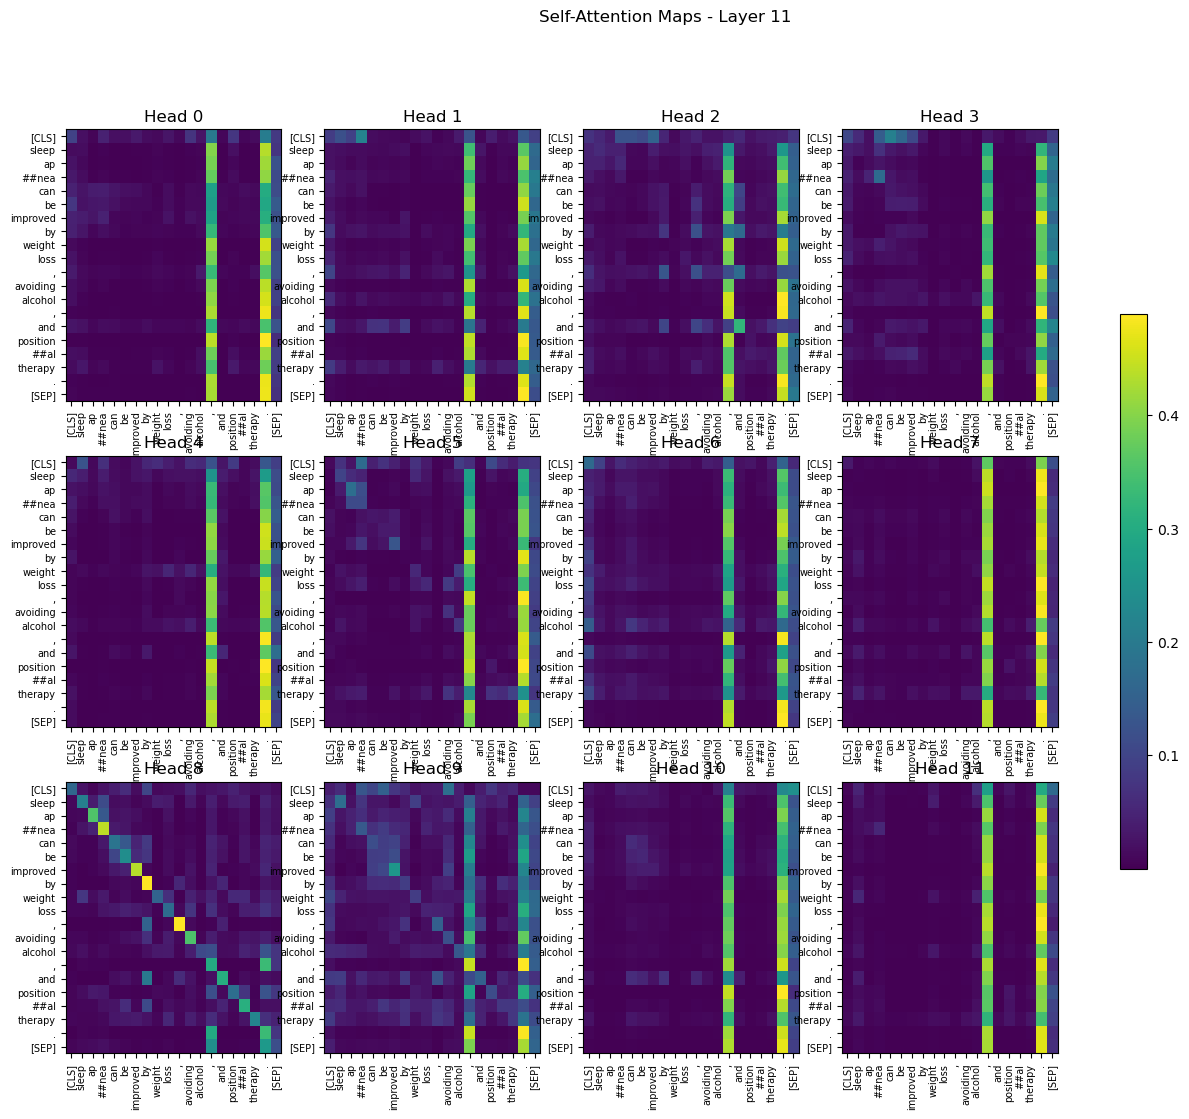

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

layer_idx = 11
attention_layer = attentions[layer_idx][0].detach().cpu().numpy()

num_heads = attention_layer.shape[0]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for head in range(num_heads):
    ax = axes[head]
    im = ax.imshow(attention_layer[head], aspect="auto")

    ax.set_title(f"Head {head}")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)

fig.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.suptitle(f"Self-Attention Maps - Layer {layer_idx}")
plt.show()

## Answer Generation

In [ ]:
import re

def split_sentences(text):
    text = text.strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [ ]:
# Get top retrieved documents for one query
def get_top_docs_for_query(qid, run_results, doc_by_pmid, top_k=10):
    pmids = [pmid for pmid, score in run_results[qid][:top_k]]
    return [doc_by_pmid[pmid] for pmid in pmids if pmid in doc_by_pmid]

In [ ]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

c:\Users\alexa\anaconda3\envs\nlp-cv-ir\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alexa\.cache\huggingface\hub\models--pritamdeka--BioBERT-mnli-snli-scinli-scitail-mednli-stsb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
def select_reference_sentences(query_text, retrieved_docs, cross_encoder, top_sentences_per_doc=3):
    selected = []

    for doc in retrieved_docs:
        pmid = doc["pmid"]
        abstract = doc["abstract"]

        sentences = split_sentences(abstract)
        if not sentences:
            continue

        pairs = [(query_text, sent) for sent in sentences]
        scores = cross_encoder.predict(pairs)

        ranked = sorted(
            zip(sentences, scores),
            key=lambda x: x[1],
            reverse=True
        )

        for sent, score in ranked[:top_sentences_per_doc]:
            selected.append({
                "pmid": pmid,
                "sentence": sent,
                "score": float(score)
            })

    return selected

### Build RAG context

In [ ]:
def build_context(reference_sentences, max_sentences=20):
    reference_sentences = sorted(
        reference_sentences,
        key=lambda x: x["score"],
        reverse=True
    )[:max_sentences]

    context_lines = []
    for i, ref in enumerate(reference_sentences, start=1):
        context_lines.append(
            f'[{i}] PMID {ref["pmid"]}: {ref["sentence"]}'
        )

    return "\n".join(context_lines)

### Answer Prompt

In [ ]:
def build_answer_prompt(question, context):
    return f"""
You are a biomedical question answering assistant.

Answer the question using ONLY the reference sentences provided below.

Rules:
- The answer must be no more than 250 words.
- Every answer sentence must include PMID citations in square brackets.
- Use this exact citation format: [PMID: 12345678].
- Use no more than 3 PMIDs per answer sentence.
- Only cite PMIDs that appear in the reference sentences.
- Each cited PMID must directly support the sentence where it is cited.
- Do not invent facts.
- Do not use outside knowledge.
- If the references do not contain enough evidence, say so and cite the closest supporting PMID.

Question:
{question}

Reference sentences:
{context}

Write the final answer only:
"""

In [ ]:
def generate_answer(question, context, llm_client):
    prompt = build_answer_prompt(question, context)
    response = llm_client(prompt)
    return response.strip()

In [ ]:
import os
import json
import uuid
import requests
import time
import ast
from dotenv import load_dotenv

API_ENDPOINT = "https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream"

load_dotenv()

API_KEY = os.getenv("IAEDU_API_KEY")
os.environ["IAEDU_API_KEY"] = "sk-usr-3owbf63h2qkoixn8rtorz5d0all1ax95v2y"

if API_KEY is None:
    raise ValueError("Missing IAEDU_API_KEY environment variable.")

def _is_uuid(text):
    try:
        uuid.UUID(text.strip())
        return True
    except (ValueError, AttributeError):
        return False
    
# def parse_iaedu_response(text):
#     import ast
#     import json

#     final_contents = []
#     stream_chunks = []

#     for raw_line in text.splitlines():
#         line = raw_line.strip()

#         if not line:
#             continue

#         if line.startswith("data:"):
#             line = line[len("data:"):].strip()

#         if line in {"[DONE]", "DONE", "Processing"}:
#             continue

#         if _is_uuid(line):
#             continue

#         obj = None
#         try:
#             obj = json.loads(line)
#         except Exception:
#             try:
#                 obj = ast.literal_eval(line)
#             except Exception:
#                 obj = None

#         if isinstance(obj, dict):
#             content = obj.get("content")

#             if content is None and isinstance(obj.get("message"), dict):
#                 content = obj["message"].get("content")

#             if content:
#                 content = str(content).strip()

#                 if "Rate limit reached" in content or "429" in content:
#                     raise RuntimeError("IAedu rate limit reached.")

#                 if not _is_uuid(content) and content.lower() != "processing":
#                     final_contents.append(content)

#             continue

#         if "Rate limit reached" in line or "429" in line:
#             raise RuntimeError("IAedu rate limit reached.")

#         stream_chunks.append(line)

#     if final_contents:
#         return final_contents[-1].strip()

#     return "".join(stream_chunks).strip()

def extract_content_if_dict_string(text):
    text = text.strip()

    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, dict) and "content" in obj:
            return obj["content"].strip()
    except Exception:
        pass

    return text

# def call_llm(prompt, thread_id=None, max_retries=5):
#     if thread_id is None:
#         thread_id = str(uuid.uuid4())

#     form_data = {
#         "channel_id": "cmoh3pa5o286kj301ga04tio8",
#         "thread_id": thread_id,
#         "user_info": "{}",
#         "message": prompt
#     }

#     headers = {
#         "x-api-key": API_KEY
#     }

#     for attempt in range(max_retries):
#         response = requests.post(
#             API_ENDPOINT,
#             data=form_data,
#             headers=headers,
#             timeout=120,
#             stream=True
#         )

#         response.raise_for_status()

#         raw_lines = []
#         for line in response.iter_lines(decode_unicode=True):
#             if line:
#                 raw_lines.append(line)

#         raw_text = "\n".join(raw_lines)

#         try:
#             parsed = parse_iaedu_response(raw_text)

#             if not parsed or _is_uuid(parsed):
#                 raise RuntimeError(
#                     "IAedu response did not contain assistant content.\n"
#                     f"Raw response:\n{raw_text}"
#                 )

#             return extract_content_if_dict_string(parsed)

#         except RuntimeError as e:
#             if "rate limit" in str(e).lower():
#                 wait = 20 * (attempt + 1)
#                 print(f"Rate limit reached. Waiting {wait}s...")
#                 # time.sleep(wait)
#                 continue
#             raise

#     raise RuntimeError("Failed after repeated IAedu rate limits.")

def parse_iaedu_response(text):
    """
    Extract the final assistant content from the IAedu stream.

    The endpoint mixes status lines, token chunks, a final AI-message repr,
    and a run id. Prefer the final message content when present; otherwise
    fall back to joining streamed token chunks without inserting newlines.
    """
    import ast

    final_contents = []
    stream_chunks = []

    for raw_line in text.splitlines():
        line = raw_line

        if line.startswith("data:"):
            line = line[len("data:"):].lstrip()

        if not line.strip():
            continue

        stripped = line.strip()
        if stripped in {"[DONE]", "DONE", "Processing"}:
            continue

        if _is_uuid(stripped):
            continue

        obj = None
        try:
            obj = json.loads(stripped)
        except Exception:
            try:
                obj = ast.literal_eval(stripped)
            except Exception:
                obj = None

        if isinstance(obj, dict):
            content = obj.get("content")
            if content is None and isinstance(obj.get("message"), dict):
                content = obj["message"].get("content")
            if content is not None and not _is_uuid(str(content)):
                final_contents.append(str(content))
            continue

        stream_chunks.append(line)

    if final_contents:
        return final_contents[-1].strip()

    return "".join(stream_chunks).strip()


def call_llm(prompt, thread_id="phase2-thread"):
    form_data = {
        "channel_id": "cmoh3pa5o286kj301ga04tio8",
        "thread_id": thread_id,
        "user_info": "{}",
        "message": prompt
    }

    headers = {
        "x-api-key": API_KEY
    }

    response = requests.post(
        API_ENDPOINT,
        data=form_data,
        headers=headers,
        timeout=120,
        stream=True
    )

    response.raise_for_status()

    raw_lines = []
    for line in response.iter_lines(decode_unicode=True):
        if line is not None:
            raw_lines.append(line)

    raw_text = "\n".join(raw_lines)
    parsed = parse_iaedu_response(raw_text)

    if not parsed or _is_uuid(parsed):
        raise RuntimeError(
            "IAedu response did not contain assistant content. "
            "It only contained a run id/status. Raw response was:\n"
            f"{raw_text}"
        )

    return extract_content_if_dict_string(parsed)

In [ ]:
print(call_llm("Reply only with: OK"))

OK


### Store Outputs

In [ ]:
phase2_outputs = {}

N_TEST_QUERIES = 2  # change to None later for all queries

items = list(queries_test.items())
if N_TEST_QUERIES is not None:
    items = items[:N_TEST_QUERIES]

for qid, query_text in tqdm(items):
    retrieved_docs = get_top_docs_for_query(
        qid,
        knn_results_test,
        doc_by_pmid,
        top_k=10
    )

    refs = select_reference_sentences(
        query_text,
        retrieved_docs,
        cross_encoder,
        top_sentences_per_doc=3
    )

    context = build_context(refs, max_sentences=20)

    answer = generate_answer(query_text, context, call_llm)

    phase2_outputs[qid] = {
        "question": query_text,
        "retrieved_pmids": [doc["pmid"] for doc in retrieved_docs],
        "reference_sentences": refs,
        "context": context,
        "answer": answer
    }

    time.sleep(1)

100%|██████████| 2/2 [00:55<00:00, 27.69s/it]


### Answer Validation

In [ ]:
import re

def count_words(text):
    return len(text.split())

def extract_pmids(text):
    return set(re.findall(r'\b\d{5,}\b', text))

def validate_answer(answer, valid_pmids):
    used_pmids = extract_pmids(answer)
    valid_pmids = set(valid_pmids)

    return {
        "word_count": count_words(answer),
        "under_250_words": count_words(answer) <= 250,
        "used_pmids": sorted(used_pmids),
        "invalid_pmids": sorted(used_pmids - valid_pmids),
        "all_pmids_valid": len(used_pmids - valid_pmids) == 0
    }

for qid, output in phase2_outputs.items():
    valid_pmids = {ref["pmid"] for ref in output["reference_sentences"]}
    output["validation"] = validate_answer(output["answer"], valid_pmids)

### Official judge prompt

In [ ]:
def build_sentence_alignment_prompt(question, answer_sentence):
    return f"""
You are an expert annotator. Given a question and an answer sentence, your task is to assign
a single label from the following list: ['Required', 'Unnecessary', 'Borderline', 'Inappropriate'].

The label definition are as follows:

Required: The answer sentence is necessary to have in the generated answer for completeness of the answers.

Unnecessary: The answer sentence is not required to have included in the generated answer.
An answer sentence may be unnecessary for several reasons:
(a) If including it would cause information overload if it is added to the answer;
(b) If it is trivial, e.g., stating that many treatment options exist.
(c) If it consists entirely of a recommendation to see a health professional.
(d) If it is not relevant to the answer.

Borderline: If an answer sentence is relevant, possibly even “good to know,” but not required,
the answer sentence may be marked borderline.

Inappropriate: The assertion may harm the patient.

Question:
{question}

Answer sentence:
{answer_sentence}

Do not generate anything else.
Respond ONLY with the label no explanation.
"""

In [ ]:
def build_answer_entailment_prompt(question, complete_answer, reference_sentences):
    return f"""
You are an expert annotator. Given a question and a complete answer and its reference
sentences, your task is to assign a single label from the following list:
['Unsupported', 'Partially Supported', 'Supported'].

The label definition are as follows:

Supported: The answer is completely supported by the reference sentences.

Partially Supported: The answer is relevant and partially supported by the reference sentences.

Unsupported: The answer is not supported by the provided sentences and may harm the patient.

Question:
{question}

Complete answer:
{complete_answer}

Reference sentences:
{reference_sentences}

Do not generate anything else.
Respond ONLY with the label no explanation.
"""

### Label Cleaning

In [ ]:
def clean_sentence_label(text):
    text = text.strip().lower()

    if "inappropriate" in text:
        return "Inappropriate"
    if "unnecessary" in text:
        return "Unnecessary"
    if "borderline" in text:
        return "Borderline"
    if "required" in text:
        return "Required"

    return "UNKNOWN"


def clean_entailment_label(text):
    text = text.strip().lower()

    if "partially" in text:
        return "Partially Supported"
    if "unsupported" in text or "unsuported" in text:
        return "Unsupported"
    if "supported" in text:
        return "Supported"

    return "UNKNOWN"

### Judge Functions

In [ ]:
def judge_sentence_alignment(question, answer_sentence):
    prompt = build_sentence_alignment_prompt(question, answer_sentence)
    raw = call_llm(prompt)
    return clean_sentence_label(raw), raw


def judge_answer_entailment(question, answer, context):
    prompt = build_answer_entailment_prompt(question, answer, context)
    raw = call_llm(prompt)
    return clean_entailment_label(raw), raw

### LLM Judge Evaluation

In [ ]:
def split_answer_sentences(answer):
    sentences = re.split(r'(?<=[.!?])\s+', answer.strip())
    return [s.strip() for s in sentences if s.strip()]

for qid, output in tqdm(phase2_outputs.items(), desc="LLM Judge"):
    question = output["question"]
    answer = output["answer"]
    context = output["context"]

    answer_sentences = split_answer_sentences(answer)

    sentence_alignment = []

    for sent in answer_sentences:
        label, raw = judge_sentence_alignment(question, sent)

        sentence_alignment.append({
            "sentence": sent,
            "label": label,
            "raw_output": raw
        })

        time.sleep(1)

    entailment_label, entailment_raw = judge_answer_entailment(
        question,
        answer,
        context
    )

    output["sentence_alignment"] = sentence_alignment
    output["answer_entailment"] = {
        "label": entailment_label,
        "raw_output": entailment_raw
    }

    time.sleep(1)

LLM Judge: 100%|██████████| 2/2 [01:55<00:00, 57.92s/it]


### Summary Table

In [ ]:
from collections import Counter
import pandas as pd

sentence_counts = Counter()
entailment_counts = Counter()

for qid, output in phase2_outputs.items():
    for item in output.get("sentence_alignment", []):
        sentence_counts[item["label"]] += 1

    entailment = output.get("answer_entailment", {}).get("label")
    if entailment:
        entailment_counts[entailment] += 1

df_sentence_alignment = pd.DataFrame(
    sentence_counts.items(),
    columns=["Label", "Count"]
).sort_values("Label")

df_entailment = pd.DataFrame(
    entailment_counts.items(),
    columns=["Label", "Count"]
).sort_values("Label")

display(df_sentence_alignment)
display(df_entailment)

,Label,Count
2,Borderline,1
0,Required,5
1,UNKNOWN,2


,Label,Count
0,UNKNOWN,2


### Save Outputs

In [ ]:
from pathlib import Path

Path("outputs/phase2").mkdir(parents=True, exist_ok=True)

with open("outputs/phase2/phase2_outputs.json", "w", encoding="utf-8") as f:
    json.dump(phase2_outputs, f, indent=2, ensure_ascii=False)

df_sentence_alignment.to_csv("outputs/phase2/sentence_alignment_summary.csv", index=False)
df_entailment.to_csv("outputs/phase2/answer_entailment_summary.csv", index=False)

### Inspection

In [ ]:
for qid, output in phase2_outputs.items():
    print("=" * 100)
    print("QID:", qid)
    print("QUESTION:")
    print(output["question"])

    print("\nANSWER:")
    print(output["answer"])

    print("\nVALIDATION:")
    print(output["validation"])

    print("\nSENTENCE ALIGNMENT:")
    for s in output.get("sentence_alignment", []):
        print("-", s["label"], ":", s["sentence"])

    print("\nANSWER ENTAILMENT:")
    print(output.get("answer_entailment", {}).get("label"))

QID: 116
QUESTION:
natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.

ANSWER:
Natural approaches to prevent and manage obstructive sleep apnea (OSA) include weight loss, avoiding central nervous system depressants, treating nasal congestion, and sleeping in the lateral position [PMID: 18651518, PMID: 21603432]. Conservative measures such as alcohol and tobacco cessation are also strongly encouraged [PMID: 21603432]. 

Complementary and integrative approaches, when combined with conventional methods, may offer some reduction in the apnea-hypopnea index, but their effectiveness as standalone treatments is not well established [PMID: 37532368, PMID: 36088151]. Nonprescription therapies, such as nasal dilators, oral lubricants, dietary supplements, and magnetic pillows, are available but lack sufficient evidence to support their utility in treating OSA [PMID: 15162258